In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit, differential_evolution
import warnings
import matplotlib.pyplot as plt

In [2]:
#Load dataset
df = pd.read_csv('../data.csv')

In [3]:
#Extract data
xData = df['Final concentration of M.B. (Cf) (mg/l)'].values
yData = df['amount of adsorbed by adsorbent at equilibrium (qe) (mg/g)'].values 

In [4]:
#Fritz-Schlunder model (4 parameters):
def func(x, C, aF, D, bF):
    return (C * (x ** aF)) / (1 + D * (x ** bF))

In [5]:
#Error function
def sum_of_squared_error(parameter_tuple):
    warnings.filterwarnings("ignore")
    val = func(xData, *parameter_tuple)
    return np.sum((yData - val) ** 2.0)

In [6]:
#Initial parameter estimation using generic algorithm
def generate_initial_parameters():
    parameter_bounds=[]
    parameter_bounds.append([0.0001, 1000]) #C bounds
    parameter_bounds.append([0.1, 5]) #aF bounds
    parameter_bounds.append([0.0001, 100]) #D bounds
    parameter_bounds.append([0.1, 5]) #bF bounds

    result = differential_evolution(sum_of_squared_error, parameter_bounds, seed=3)
    return result.x

In [7]:
#Generate initial parameters
genetic_parameters = generate_initial_parameters()

In [10]:
#Curve fitting
fitted_parameters, pcov = curve_fit(func, xData, yData, genetic_parameters,bounds=([0.0001, 0.1, 0.0001, 0.1], [1000, 5, 100, 5]), maxfev=30000)

C, aF, D, bF = fitted_parameters
print(f'Parameters (C, aF, D, bF)=({C}, {aF}, {D}, {bF})')

Parameters (C, aF, D, bF)=(81.76568167719928, 1.9521201246621211, 99.99999989655474, 1.3759248556593664)


In [11]:
#Predictions
model_predictions = func(xData, *fitted_parameters)

In [12]:
#Error Calculation
absolute_error = abs(model_predictions - yData)
squared_error = np.square(absolute_error)
mse = np.mean(squared_error)
rmse = np.sqrt(mse)
n=len(yData)
p=4 #no. of parameters

hybrid = (100.0/(n-p)) * np.sum(squared_error/yData)
mpsd = 100.0*np.sqrt((1.0/(n-p)) * np.sum(np.square(absolute_error/yData)))
chi_square = np.sum(squared_error/yData)

In [13]:
#Output results
print('ERRSQ:      ', np.sum(squared_error))
print('RMSE:       ', rmse)
print('HYBRID:     ', hybrid)
print('EABS:       ', np.sum(absolute_error))
print('MPSD:       ', mpsd)
print('Chi-square: ', chi_square)

ERRSQ:       0.001753349393779964
RMSE:        0.014804346463876596
HYBRID:      0.0575301820211899
EABS:        0.10707123019725664
MPSD:        3.529196195840211
Chi-square:  0.002301207280847596


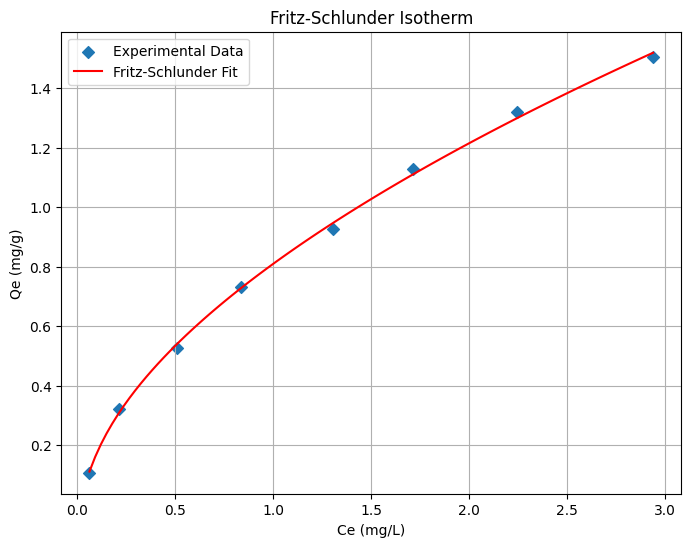

In [14]:
#Plotting
def plot():
    plt.figure(figsize=(8,6))

    #Scatter plot
    plt.scatter(xData, yData, marker='D', label='Experimental Data')

    #Model Curve
    xModel = np.linspace(min(xData), max(xData), 100)
    yModel = func(xModel, *fitted_parameters)

    plt.plot(xModel, yModel,color='red', label='Fritz-Schlunder Fit')

    plt.title('Fritz-Schlunder Isotherm')
    plt.xlabel('Ce (mg/L)')
    plt.ylabel('Qe (mg/g)')
    plt.legend()
    plt.grid()

    plt.show()

plot()